# Clasificador de Rango Etario — UTKFace

Clasificación multiclase (5 clases) a partir de imágenes de rostros, implementado en **PyTorch** y **TensorFlow/Keras**.

**Rangos etarios:**

| Clase | Rango | Etiqueta |
|---|---|---|
| 0 | 0–12 | niño |
| 1 | 13–19 | adolescente |
| 2 | 20–35 | joven |
| 3 | 36–59 | adulto |
| 4 | 60+ | viejo |

> ## 📌 Notebook de RESULTADOS — Banco: UTKFace COMPLETO (desbalanceado)
>
> **Este notebook conserva los resultados (tablas, gráficos, matrices de confusión y curvas) de la corrida de referencia.** No re-ejecutar si se quieren mantener estos resultados.
>
> **Banco de imágenes de entrenamiento:** UTKFace completo, tal como viene del dataset original.
> - Carpeta: `./UTKFace_data/UTKFace`
> - Imágenes únicas válidas: **23.705** (23.708 archivos, 3 descartados por nombre mal formado)
> - **Distribución desbalanceada por clase:**
>
> | Clase | Etiqueta | N° imágenes |
> |---|---|---|
> | 0 | niño (0–12) | 3.413 |
> | 1 | adolescente (13–19) | 1.180 |
> | 2 | joven (20–35) | 10.514 |
> | 3 | adulto (36–59) | 5.910 |
> | 4 | viejo (60+) | 2.688 |
>
> **Configuración:** IMG_SIZE=64 · BATCH_SIZE=32 · SEED=42 · split estratificado 70/15/15 (Train 16.593 · Val 3.556 · Test 3.556) · 10 épocas · CNN 3 conv + 2 FC · Adam lr=1e-3 · dispositivo: **CPU**.
>
> **Resultado resumido:** PyTorch val_acc ≈ 0.74 · Keras val_acc ≈ 0.72. El desbalance penaliza sobre todo a *adolescente* y *viejo* (clases minoritarias), que se confunden con *joven*/*adulto*.
>
> 👉 Comparar con `clasificador_edad_utkface.ipynb`, entrenado sobre el banco **balanceado** (`dataset_etiquetado`, 1.180 imágenes por clase).

## 0. Descarga del dataset (UTKFace)

**Opción A — Kaggle API (recomendado):**

```bash
pip install kaggle
# 1. Crea una cuenta en kaggle.com si no tienes
# 2. Ve a kaggle.com/settings -> API -> "Create New Token" (descarga kaggle.json)
# 3. Coloca kaggle.json en ~/.kaggle/kaggle.json (Linux/Mac) o C:\Users\<usuario>\.kaggle\kaggle.json (Windows)

kaggle datasets download -d jangedoo/utkface-new
unzip utkface-new.zip -d ./UTKFace_data
```

**Opción B — Descarga manual:**

1. Ve a https://www.kaggle.com/datasets/jangedoo/utkface-new
2. Descarga el .zip (botón Download)
3. Descomprime y deja la carpeta de imágenes en `./UTKFace_data/UTKFace/` (debe contener directamente los .jpg, sin subcarpetas extra)

**Estructura esperada:**
```
UTKFace_data/
  UTKFace/
    1_0_0_20161219140623097.jpg
    2_1_3_20170109150557335.jpg
    ...
```

El nombre de cada archivo sigue el formato `[edad]_[género]_[raza]_[fecha].jpg`. Solo usaremos el campo `edad`.

In [1]:
!pip install pandas matplotlib seaborn scikit-learn torch tensorflow pillow

In [2]:
# --- Configuración general ---
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

DATA_DIR = "./UTKFace_data/UTKFace"   # <-- ajusta esta ruta si tu carpeta quedó en otro lugar
IMG_SIZE = 64                          # tamaño al que se redimensionan las imágenes
BATCH_SIZE = 32
SEED = 42

np.random.seed(SEED)

In [3]:
# --- Definición de los rangos etarios ---
CLASS_NAMES = ["nino", "adolescente", "joven", "adulto", "viejo"]

def age_to_bucket(age: int) -> int:
    """Convierte una edad entera al índice de clase (0-4) según los rangos definidos."""
    if age <= 12:
        return 0  # nino
    elif age <= 19:
        return 1  # adolescente
    elif age <= 35:
        return 2  # joven
    elif age <= 59:
        return 3  # adulto
    else:
        return 4  # viejo

def parse_age_from_filename(filename: str):
    """Extrae la edad desde un nombre de archivo tipo '23_0_1_2017...jpg'. Devuelve None si no calza el formato."""
    base = os.path.basename(filename)
    match = re.match(r"^(\d+)_\d+_\d+_.+\.jpg$", base)
    if match is None:
        return None
    return int(match.group(1))

In [4]:
# --- Construcción del dataframe (ruta de imagen + edad + clase) ---
filepaths = glob.glob(os.path.join(DATA_DIR, "*.jpg"))
print(f"Imágenes encontradas: {len(filepaths)}")

records = []
skipped = 0
for fp in filepaths:
    age = parse_age_from_filename(fp)
    if age is None or age > 116:  # 116 es la edad máxima reportada en UTKFace; filtramos basura
        skipped += 1
        continue
    records.append({"filepath": fp, "age": age, "label": age_to_bucket(age)})

df = pd.DataFrame(records)
print(f"Imágenes válidas: {len(df)}  |  Descartadas (nombre mal formado): {skipped}")
df.head()

Imágenes encontradas: 23708
Imágenes válidas: 23705  |  Descartadas (nombre mal formado): 3


,filepath,age,label
0,./UTKFace_data/UTKFace\100_0_0_201701122135009...,100,4
1,./UTKFace_data/UTKFace\100_0_0_201701122152403...,100,4
2,./UTKFace_data/UTKFace\100_1_0_201701101837263...,100,4
3,./UTKFace_data/UTKFace\100_1_0_201701122130019...,100,4
4,./UTKFace_data/UTKFace\100_1_0_201701122133036...,100,4


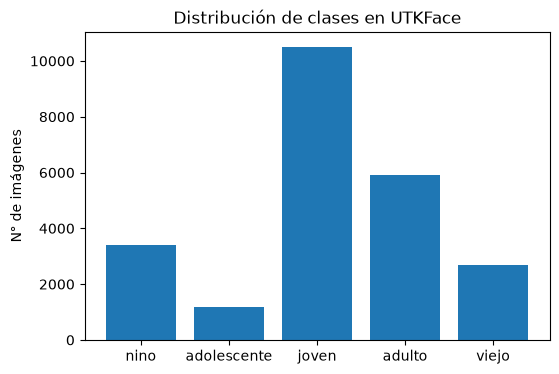

label
0     3413
1     1180
2    10514
3     5910
4     2688
Name: count, dtype: int64


In [5]:
# --- Distribución de clases ---
counts = df["label"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar([CLASS_NAMES[i] for i in counts.index], counts.values)
plt.title("Distribución de clases en UTKFace")
plt.ylabel("N° de imágenes")
plt.show()

print(counts)
# Nota: UTKFace suele estar desbalanceado (pocos 'viejo' y 'adolescente').
# Si el desbalance es muy fuerte, considera usar class_weight (Keras) o
# WeightedRandomSampler (PyTorch) más adelante.

In [6]:
# --- Split train / val / test (estratificado por clase) ---
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df["label"], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=SEED)

print(f"Train: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")

Train: 16593  |  Val: 3556  |  Test: 3556


## Parte A — PyTorch

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import time
import torchvision.transforms as T

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

class UTKFaceDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, row["label"]

train_ds = UTKFaceDataset(train_df, transform)
val_ds = UTKFaceDataset(val_df, transform)
test_ds = UTKFaceDataset(test_df, transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

Device: cpu


In [8]:
# --- Arquitectura CNN simple ---
class AgeCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        # IMG_SIZE=64 -> tras 3 poolings de /2: 64 -> 32 -> 16 -> 8
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

model_pt = AgeCNN(num_classes=len(CLASS_NAMES)).to(device)
print(model_pt)

AgeCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=5, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


In [9]:
# --- Entrenamiento (PyTorch) ---
ti_pt = time.time()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_pt.parameters(), lr=1e-3)
EPOCHS = 10

def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if train:
                optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += imgs.size(0)
    return total_loss / total, correct / total

history_pt = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
for epoch in range(EPOCHS):
    tr_loss, tr_acc = run_epoch(model_pt, train_loader, train=True)
    va_loss, va_acc = run_epoch(model_pt, val_loader, train=False)
    history_pt["train_loss"].append(tr_loss); history_pt["train_acc"].append(tr_acc)
    history_pt["val_loss"].append(va_loss); history_pt["val_acc"].append(va_acc)
    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | val_loss={va_loss:.4f} val_acc={va_acc:.4f}")

tf_pt = time.time()
t_total_pt = tf_pt - ti_pt
print(f"\nTiempo total de entrenamiento (PyTorch): {t_total_pt:.2f} segundos")

Epoch 1/10 | train_loss=1.0439 train_acc=0.5838 | val_loss=0.8726 val_acc=0.6524
Epoch 2/10 | train_loss=0.8359 train_acc=0.6721 | val_loss=0.7787 val_acc=0.6856
Epoch 3/10 | train_loss=0.7531 train_acc=0.6944 | val_loss=0.7441 val_acc=0.6949
Epoch 4/10 | train_loss=0.6986 train_acc=0.7169 | val_loss=0.7215 val_acc=0.7013
Epoch 5/10 | train_loss=0.6533 train_acc=0.7293 | val_loss=0.6981 val_acc=0.7084
Epoch 6/10 | train_loss=0.6113 train_acc=0.7516 | val_loss=0.7157 val_acc=0.7160
Epoch 7/10 | train_loss=0.5704 train_acc=0.7663 | val_loss=0.6993 val_acc=0.7140
Epoch 8/10 | train_loss=0.5266 train_acc=0.7844 | val_loss=0.6842 val_acc=0.7219
Epoch 9/10 | train_loss=0.4892 train_acc=0.7961 | val_loss=0.7249 val_acc=0.7191
Epoch 10/10 | train_loss=0.4508 train_acc=0.8153 | val_loss=0.7856 val_acc=0.7199

Tiempo total de entrenamiento (PyTorch): 1063.05 segundos


              precision    recall  f1-score   support

        nino       0.91      0.90      0.91       512
 adolescente       0.51      0.15      0.23       177
       joven       0.75      0.84      0.79      1577
      adulto       0.57      0.64      0.61       887
       viejo       0.81      0.45      0.58       403

    accuracy                           0.72      3556
   macro avg       0.71      0.60      0.62      3556
weighted avg       0.72      0.72      0.71      3556



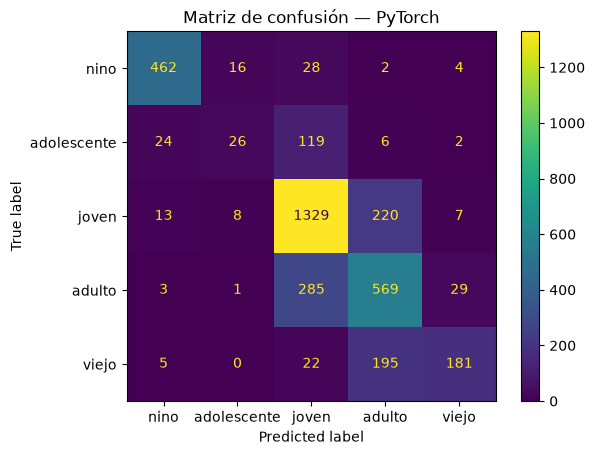

In [10]:
# --- Evaluación en test (PyTorch) ---
model_pt.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model_pt(imgs)
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))
cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot()
plt.title("Matriz de confusión — PyTorch")
plt.show()

## Parte B — TensorFlow / Keras

In [11]:
import tensorflow as tf

def load_and_preprocess(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img, label

def make_tf_dataset(dataframe, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((dataframe["filepath"].values, dataframe["label"].values))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds_tf = make_tf_dataset(train_df, shuffle=True)
val_ds_tf = make_tf_dataset(val_df)
test_ds_tf = make_tf_dataset(test_df)

In [12]:
# --- Arquitectura CNN equivalente, en Keras ---
model_tf = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(CLASS_NAMES), activation="softmax"),
])

model_tf.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model_tf.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 548,645 (2.09 MB)

 Trainable params: 548,645 (2.09 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# --- Entrenamiento (Keras) ---
ti2=time.time()
EPOCHS_TF = 10
history_tf = model_tf.fit(train_ds_tf, validation_data=val_ds_tf, epochs=EPOCHS_TF)
tf2=time.time()
t_total_tf = tf2 - ti2
print(f"\nTiempo total de entrenamiento (Keras): {t_total_tf:.2f} segundos")

Epoch 1/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.5576 - loss: 1.1099 - val_accuracy: 0.6682 - val_loss: 0.8467
Epoch 2/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.6644 - loss: 0.8452 - val_accuracy: 0.6867 - val_loss: 0.7640
Epoch 3/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 40s 55ms/step - accuracy: 0.6941 - loss: 0.7636 - val_accuracy: 0.6969 - val_loss: 0.7567
Epoch 4/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 38s 52ms/step - accuracy: 0.7122 - loss: 0.7171 - val_accuracy: 0.7064 - val_loss: 0.7131
Epoch 5/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 54s 71ms/step - accuracy: 0.7336 - loss: 0.6662 - val_accuracy: 0.7236 - val_loss: 0.6635
Epoch 6/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 71s 54ms/step - accuracy: 0.7430 - loss: 0.6325 - val_accuracy: 0.7261 - val_loss: 0.6710
Epoch 7/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 61s 97ms/step - accuracy: 0.7535 - loss: 0.6045 - val_accuracy: 0.7312 - val_loss: 0.6632
Epoch 8/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 72s 101ms/step - accuracy: 0.7677 - loss: 0.5656 -

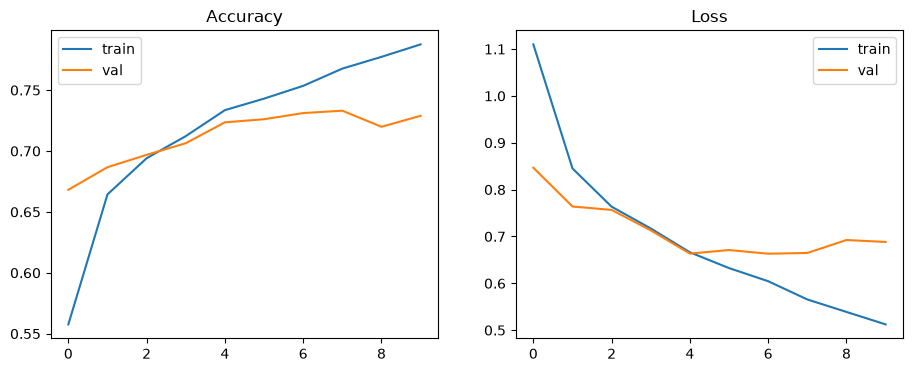

In [14]:
# --- Curvas de entrenamiento (Keras) ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history_tf.history["accuracy"], label="train")
axes[0].plot(history_tf.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy"); axes[0].legend()
axes[1].plot(history_tf.history["loss"], label="train")
axes[1].plot(history_tf.history["val_loss"], label="val")
axes[1].set_title("Loss"); axes[1].legend()
plt.show()

              precision    recall  f1-score   support

        nino       0.93      0.89      0.91       512
 adolescente       0.43      0.42      0.42       177
       joven       0.76      0.82      0.79      1577
      adulto       0.61      0.59      0.60       887
       viejo       0.78      0.62      0.69       403

    accuracy                           0.73      3556
   macro avg       0.70      0.67      0.68      3556
weighted avg       0.73      0.73      0.73      3556



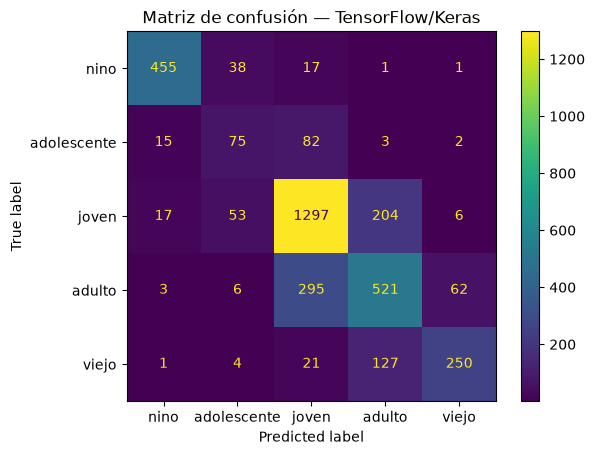

In [15]:
# --- Evaluación en test (Keras) ---
y_true_tf, y_pred_tf = [], []
for imgs, labels in test_ds_tf:
    preds = model_tf.predict(imgs, verbose=0)
    y_pred_tf.extend(np.argmax(preds, axis=1))
    y_true_tf.extend(labels.numpy())

print(classification_report(y_true_tf, y_pred_tf, target_names=CLASS_NAMES))
cm_tf = confusion_matrix(y_true_tf, y_pred_tf)
ConfusionMatrixDisplay(cm_tf, display_labels=CLASS_NAMES).plot()
plt.title("Matriz de confusión — TensorFlow/Keras")
plt.show()

## Comparación final

_(Completa aquí: accuracy de cada framework en test, qué clases se confunden más entre sí — probablemente 'joven' vs 'adulto' y 'adolescente' vs 'joven' por la ambigüedad visual en los límites de rango — y qué cambiarías para mejorar el modelo: más datos, balanceo de clases, augmentación, transfer learning, etc.)_